In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [42]:
N_particles = 4000
Box_size = 17.1

In [43]:
data = np.loadtxt("output/start_position_file.csv", delimiter=";")

x = data[:, 0]
y = data[:, 1]
c = data[:, 3]

print(f"Total charge: {sum(c)}")

Total charge: 0.0


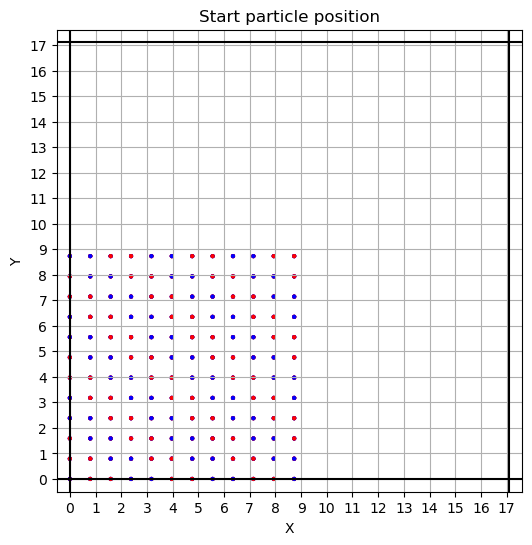

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=4, c=c, cmap='bwr')

ax.set_title("Start particle position")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_xlim([-0.5,Box_size + 0.5])
ax.set_ylim([-0.5,Box_size + 0.5])
ax.set_xticks(np.arange(0, Box_size, step=1))
ax.set_yticks(np.arange(0, Box_size, step=1))

ax.axvline(x=0,c="k")
ax.axvline(x=Box_size,c="k")
ax.axhline(y=0,c="k")
ax.axhline(y=Box_size,c="k")

ax.grid(True)

plt.show()

In [45]:
data = np.loadtxt("output/end_position_file.csv", delimiter=";")

x = data[:, 0]
y = data[:, 1]

/tmp/ipykernel_3546/17764675.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=4, cmap="bwr")


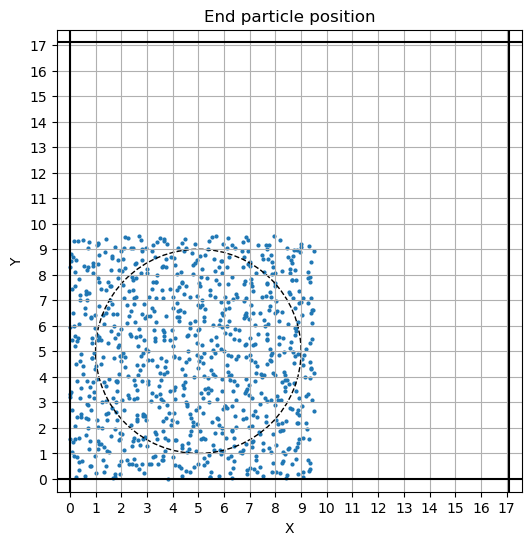

In [46]:


fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=4, cmap="bwr")

ax.set_title("End particle position")
ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_xlim([-0.5,Box_size + 0.5])
ax.set_ylim([-0.5,Box_size + 0.5])
ax.set_xticks(np.arange(0, Box_size, step=1))
ax.set_yticks(np.arange(0, Box_size, step=1))

ax.axvline(x=0,c="k")
ax.axvline(x=Box_size,c="k")
ax.axhline(y=0,c="k")
ax.axhline(y=Box_size,c="k")

ax.grid(True)

circle = plt.Circle((5, 5), 4, color='k', fill=False,linestyle='dashed',label="Cutoff")
ax.add_patch(circle)


plt.show()


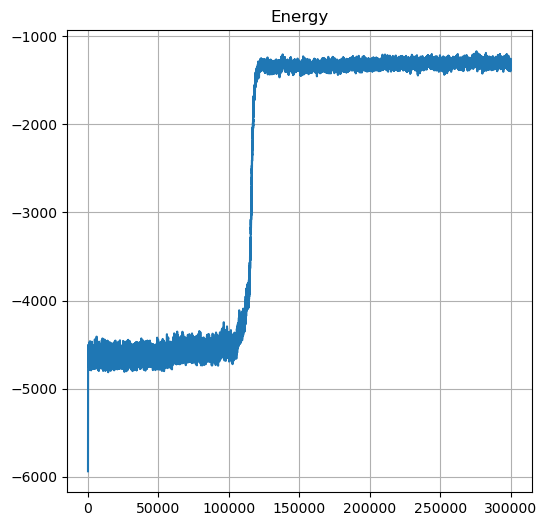

In [47]:
energy = np.loadtxt("output/energy.csv", delimiter=";")

# Plot
plt.figure(figsize=(6, 6))
plt.plot(energy)

plt.title("Energy")
plt.grid(True)
plt.show()

data = np.loadtxt("output/specific_heat.csv", delimiter=";")
T = data[:,0]
CV = data[:,1]
# Plot
plt.figure(figsize=(6, 6))
plt.plot(T,CV, "-o")

plt.title("")
plt.grid(True)
plt.xlabel("T")
plt.ylabel("Cv")
plt.show()

In [48]:
data = np.loadtxt("output/radial_distribution.csv", delimiter=";")

# Plot
plt.figure(figsize=(6, 6))
plt.plot(data[:,0], data[:,1])

plt.title(r"Radial distribution g(r) with params T = 8, $\rho$ = 0.1, N = 500")
plt.xlabel(r"r [$\sigma$]")
plt.ylabel("g(r)")

plt.grid(True)
plt.show()

/tmp/ipykernel_3546/3508688002.py:1: UserWarning: loadtxt: input contained no data: "output/radial_distribution.csv"
  data = np.loadtxt("output/radial_distribution.csv", delimiter=";")


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

<Figure size 600x600 with 0 Axes>

Tempo di autocorrelazione integrato τ_int = 51.81 MC steps
Campioni indipendenti ~ 101.3298059917994


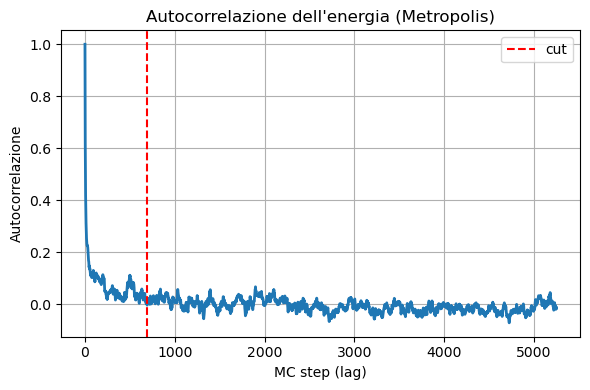

In [ ]:
# ATTENTION CODE GENERATED WITH CHAT GPT JUST TO GET A FAST RESULT AND CHECK SOME STUFF


import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
file_energy = "output/energy.csv"
delimiter = ";"
thermal_frac = 0.3     # frazione da scartare (30%)
max_lag = None         # None = usa tutta la serie

# =========================
# Caricamento dati
# =========================
energy = np.loadtxt(file_energy, delimiter=delimiter)

# =========================
# Scarto termalizzazione
# =========================
n0 = int(len(energy) * thermal_frac)
energy = energy[n0:]

# =========================
# Fluttuazioni
# =========================
E = energy - np.mean(energy)
N = len(E)

# =========================
# Autocorrelazione (O(N log N))
# =========================
f = np.fft.fft(E, n=2*N)
acf = np.fft.ifft(f * np.conjugate(f)).real[:N]
acf /= acf[0]  # normalizzazione

# =========================
# Taglio lag
# =========================
if max_lag is None:
    max_lag = N // 2

acf = acf[:max_lag]
lags = np.arange(max_lag)

# =========================
# Tempo di autocorrelazione integrato
# τ_int = 1/2 + sum_{t=1}^∞ C(t)
# (taglio al primo valore negativo)
# =========================
neg = np.where(acf < 0)[0]
cut = neg[0] if len(neg) > 0 else max_lag

tau_int = 0.5 + np.sum(acf[1:cut])

print(f"Tempo di autocorrelazione integrato τ_int = {tau_int:.2f} MC steps")
print("Campioni indipendenti ~", N / (2 * tau_int))

# =========================
# Grafico (opzionale)
# =========================
plt.figure(figsize=(6,4))
plt.plot(lags, acf, lw=2)
plt.axvline(cut, color="r", ls="--", label="cut")
plt.xlabel("MC step (lag)")
plt.ylabel("Autocorrelazione")
plt.title("Autocorrelazione dell'energia (Metropolis)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

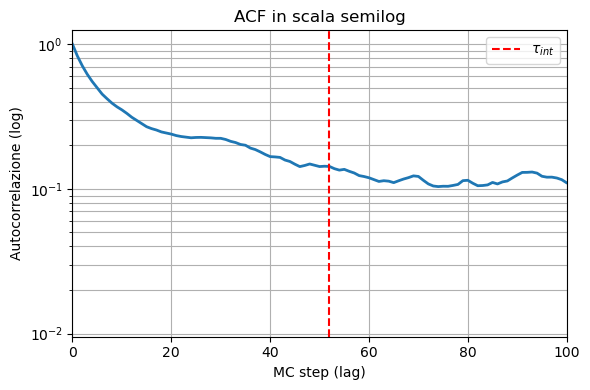

In [ ]:
plt.figure(figsize=(6,4))
plt.semilogy(lags[:500], acf[:500], lw=2)
plt.axvline(tau_int, color="r", ls="--", label=r"$\tau_{int}$")
plt.xlabel("MC step (lag)")
plt.ylabel("Autocorrelazione (log)")
plt.title("ACF in scala semilog")
plt.grid(True, which="both")
plt.legend()
plt.xlim([0,100])
plt.tight_layout()
plt.show()